#1. Generate Dataset (50 Samples)
#Create classification label (Healthy 1, Unhealthy= 0)
Sample Data:
    Soil_Nitrogen    Rainfall  Temperature  Water_Usage  Label
0      74.967142  632.408397    17.923146   420.039428      1
1      68.617357  561.491772    22.896773   427.715857      1
2      76.476885  532.307800    23.286427   345.598022      0
3      85.230299  661.167629    20.988614   418.580296      1
4      67.658466  703.099952    24.193571   423.445798      1
#2. Split Features and Labels
#3. Train-Test Split
#4. Feature Scaling
#5. Build ANN Model
#Input + Hidden Layers
#Output Layer (Binary Classification)
#6. Compile Model
#7. Train Model
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7000 - loss: 0.6920
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7000 - loss: 0.6741 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6250 - loss: 0.6612 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6250 - loss: 0.6479 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6250 - loss: 0.6349 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6500 - loss: 0.6246 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6250 - loss: 0.6120 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6250 - loss: 0.6013 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6250 - loss: 0.5920 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7000 - loss: 0.5830 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6750 - loss: 0.5736 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6750 - loss: 0.5658 
Epoch 13/50
8

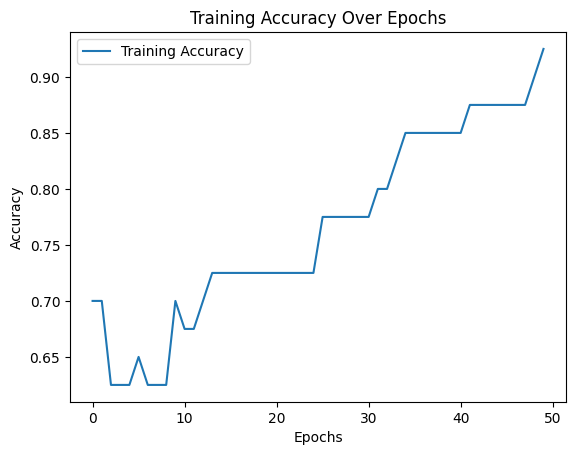

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("#1. Generate Dataset (50 Samples)")
np.random.seed(42)
n_samples=50

data=pd.DataFrame({

'Soil_Nitrogen': np.random.normal(70, 10, n_samples),
'Rainfall': np.random.normal(600, 100, n_samples),
'Temperature': np.random.normal(25, 5, n_samples),
'Water_Usage': np.random.normal (400, 80, n_samples)
})


print("#Create classification label (Healthy 1, Unhealthy= 0)")
data['Label']=(
(data['Soil_Nitrogen'] > 65) &
(data['Rainfall'] > 550) &
(data['Water_Usage'] > 350)
).astype(int)
print("Sample Data:\n", data.head())


print("#2. Split Features and Labels")
X=data.drop('Label', axis=1)
y= data['Label']


print("#3. Train-Test Split")
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )


print("#4. Feature Scaling")
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


print("#5. Build ANN Model")
model=Sequential()

print("#Input + Hidden Layers")
model.add(Dense(8, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(6, activation='relu'))

print("#Output Layer (Binary Classification)")
model.add(Dense(1, activation='sigmoid'))


print("#6. Compile Model")
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)


print("#7. Train Model")
history=model.fit(
X_train, y_train, epochs=50, batch_size=5, verbose=1 )


print("#8. Predictions")
y_pred=model.predict(X_test)
y_pred=(y_pred > 0.5).astype(int)


print("#9. Evaluation Metrics")
print("\n--- Model Evaluation ---")
accuracy=accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n",classification_report(y_test,y_pred))


print("# 10. Plot Training Performance")
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.legend()
plt.show()